In [1]:
import sys

import os

In [2]:
import torch
from torch import nn
from torch.nn import functional as F


import wandb
import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from torch.utils.data import DataLoader
from xaikd.utils import metrics
from xaikd import models, datasets

from contextlib import nullcontext

from datetime import datetime

from matplotlib import colormaps

from xaikd.models.vgg import canonize_model


from zennit.attribution import Gradient
from zennit.composites import EpsilonGammaBox, EpsilonPlusFlat
from xaikd import datasets, models, utils

from torchvision import transforms

from collections import OrderedDict

In [3]:
api = wandb.Api()

In [4]:
PROJECT = "p16i/xaikd-distillation-layerwise-s27"
EXPERIMENT_GROUP = "./artifacts/2024-05-s27/experiments/3-parameter-partition-modes"

In [5]:
def read_data(
    teacher,
    student,
    dataset,
    policy,
    lambda_task,
    lambda_kd,
    lambda_layer,
    training_size,
    contamination_level,
    parameter_partition_mode,
    verbose=False,
    return_raw = False,
    accuracy_mode="last_checkpoint"
):
    
    
    runs = api.runs(
        PROJECT,
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.lambda_layer": lambda_layer},
            {"config.policy": policy},
            {"config.dataset": dataset},
            {"config.training_size": training_size},
            {"config.parameter_partition_mode": parameter_partition_mode},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    datasets = []
    for run in runs:
        seed = run.config["seed"]
        if not "arr_metrics"in run.summary:
            print(">> bad run config (id={rn}")
            print(run.config)
            count += 1
            return run
            continue
                                 
        if accuracy_mode == "last_checkpoint":
            k = -1
        else:
            raise
    
        datasets.append(run.config["dataset"])

        for epoch in range(run.config["epochs"]):
            
            epoch_val_acc = run.summary["arr_metrics"]["val_acc"][epoch]
        
            epoch_train_acc = run.summary["arr_metrics"]["train_acc"][epoch]


            rows.append(
                dict(
                    best_epoch=k,
                    seed=seed, 
                    lambda_task=run.config["lambda_task"],
                    lambda_kd=run.config["lambda_kd"],
                    # remark: this is the actual value used in distillation
                    # cf. https://github.com/p16i/xai-kd/blob/2023-09-s14--1-teacher-training-script/scripts/distill-layerwise.py#L364
                    lambda_layer=run.config["policy_lambda_layer"],
                    epoch=epoch,
                    val_acc=epoch_val_acc, 
                    train_acc=epoch_train_acc,
                    teacher_acc=run.summary["teacher_acc"],
                    policy=run.config["policy"],
                    run_id=run.id
                )
            )

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
    # df = df.sort_values(by=["lambda_layer", "seed"], ascending=True)
        
        
    if return_raw:
        return df
        
    df = df.groupby(by="epoch").agg(
        {
            "val_acc": ["mean", "std", "count"],
            "train_acc": ["mean", "std", "count"],

            "teacher_acc": ["mean"],
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        3
    )
    
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="imagenet-vgg16-tv",
    dataset="imagenet-butterfly-spurious0.5",
    student="vggcustomimagenetdims-32-24-24-10",
    lambda_task=0.0,
    lambda_kd=1.0,
    lambda_layer=1.0,
    policy="basis-identity:pca--uncentered",
    training_size=0.125,
    verbose=True,
    contamination_level=0.0,
    parameter_partition_mode="@50",
    return_raw=False,
)

summary

we have 3 runs
df.shape: (100, 8)


epoch   val_acc                 train_acc                 teacher_acc
              mean       std count      mean       std count        mean
0      0  0.224444  0.055210     3  0.197188  0.027841     3    0.956667
1      1  0.245556  0.025019     3  0.237654  0.035654     3    0.956667
2      2  0.270000  0.041633     3  0.279150  0.016663     3    0.956667
3      3  0.317778  0.030972     3  0.283265  0.033327     3    0.956667
4      4  0.366667  0.043333     3  0.320645  0.043373     3    0.956667
..   ...       ...       ...   ...       ...       ...   ...         ...
95    95  0.846667  0.003333     3  0.844993  0.002970     3    0.956667
96    96  0.857778  0.007698     3  0.839849  0.006694     3    0.956667
97    97  0.850000  0.013333     3  0.820645  0.005666     3    0.956667
98    98  0.856667  0.000000     3  0.845679  0.005346     3    0.956667
99    99  0.856667  0.014530     3  0.837792  0.004752     3    0.956667

[100 rows x 8 columns]

In [6]:
def alias(name):
        __dd = {
            "basis-identity:random--uncentered": "Random Subspace",
            "basis-identity:pca--uncentered": "PCA",
            "basis-identity:pcalookahead--uncentered": "PCA-AH",
            "basis-identity:prca-sortabs--uncentered": "PRCA-sortabs",
            "vid": "VID",
            "nothing": "KD Only"

        }
        return __dd.get(name, name)
    
def color(name):
        __dd = {
            "basis-identity:random--uncentered": "lightgray"
        }
        return __dd.get(name, None)
    
def marker(name):
    if "pca" in name or "prca" in name:
        return "s"
    elif "vid" in name:
        return "x"
    else:
        return '.'

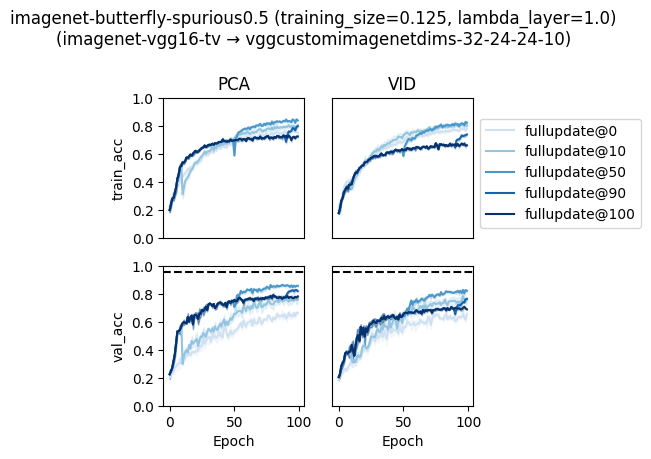

In [19]:
def ls(name):
    return '-'
    
    if name == "@0":
        return "-"
    else:
        return "--"
        
def viz(dataset, detach_output, lambda_layer):

    
    lambda_task = 0.0
    lambda_kd = 1.0
    
    teacher = "imagenet-vgg16-tv"
    student = "vggcustomimagenetdims-32-24-24-10"

    
    arr_policies = [
         #       "basis-identity:pcalookahead--uncentered",

        "basis-identity:pca--uncentered",
        "vid",
#        "basis-identity:prca-sortabs--uncentered",

        #"vid",
        #"attention-transfer",
        #"basis-identity:random--uncentered"
    ]

    arr_parameter_modes = [
        "@0",
        "@10",
        "@50",
        "@90",
        "@100"
    ]
    
    trainining_size = 0.125
    ncols = len(arr_policies)
    nrows = 2
    num_policies = len(arr_policies)
    
    plt.figure(figsize=(2*ncols, 2*nrows))

    plt.suptitle(f"{dataset} (training_size={trainining_size}, lambda_layer={lambda_layer})\n({teacher} → {student})", y=1.1)


    cmap = plt.cm.Blues
    
    for pix, policy in enumerate(arr_policies):

        for dix, col_name in enumerate(["train_acc", "val_acc"]):
            plt.subplot(nrows, ncols, dix*ncols + pix+1)
                    
            for mix, parameter_partition_mode in enumerate(arr_parameter_modes):
                df = read_data(
                    teacher=teacher,
                    dataset=dataset,
                    student=student,
                    lambda_task=lambda_task,
                    lambda_kd=lambda_kd,
                    lambda_layer=lambda_layer,
                    policy=policy,
                    training_size=trainining_size,
                    contamination_level=0.0,
                    parameter_partition_mode=parameter_partition_mode
                )
                ticks = df["epoch"]
                mean = df[col_name]["mean"]
                stderr = df[col_name]["std"] / (df[col_name]["count"].values[-1] ** 0.5)
                
                plt.plot(
                    ticks,
                    mean, 
                    ls=ls(parameter_partition_mode),
                    label=f"fullupdate{parameter_partition_mode}",
                    color=cmap( (mix/ len(arr_parameter_modes)) + 0.2 ),
                    #marker="." if parameter_partition_mode == "@10" else ""
                )
                plt.fill_between(
                    ticks,
                    mean - stderr,
                    mean + stderr,
                    color=plt.gca().lines[-1].get_color(),
                    alpha=0.2
                )
            
            if dix == 0:
                plt.title(alias(policy))
                
            if col_name == "val_acc":
                teacher_acc = df["teacher_acc"].values[0] 
                plt.axhline(teacher_acc, ls="--", label="Teacher", color="k")
                plt.xlabel("Epoch")
            else:
                plt.xticks([])
            plt.ylim([0.0, 1])

            if pix == len(arr_policies) - 1 and dix == 0:
                plt.legend(bbox_to_anchor=(1.0, 0.9))
            if pix ==  0 :
                plt.ylabel(col_name)
            else:
                plt.yticks([])

            
viz(dataset="imagenet-butterfly-spurious0.5", detach_output=True, lambda_layer=1.0)

In [ ]:
viz(dataset="imagenet-butterfly", detach_output=True, lambda_layer=1.0)

In [8]:
plt.cm.Blues(-1)

(0.9686274509803922, 0.984313725490196, 1.0, 1.0)